## 3_4 Training using XGBOOST

In [45]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix , PrecisionRecallDisplay , balanced_accuracy_score, matthews_corrcoef
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold
import numpy as np
from sklearn.model_selection import RandomizedSearchCV , learning_curve
from sklearn.utils import resample
import matplotlib.pyplot as plt

In [47]:
data = pd.read_csv('ds/Fraud_cleaned_dataset.csv' , nrows=300000)
data.head(1)

,Unnamed: 0,category,amt,gender,lat,long,city_pop,job,merch_lat,merch_long,is_fraud,trans_hour,trans_month,trans_day,trans_year,age
0,0,8,-0.407826,0,-0.48442,0.65762,-0.282589,370,-0.494354,0.593864,0,-1.878145,-1.504564,-1.652258,-0.634065,-0.890761


In [48]:
# target
y = data['is_fraud']

# features rest columns
X = data.drop(columns=['is_fraud'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [49]:
#search best parameters

param_distributions = {
    'learning_rate' : [0.001, 0.01, 0.02, 0.04, 0.06, 0.08, 0.1],
    'n_estimators': range(10 , 250 , 20)
}

random_search = RandomizedSearchCV(
    estimator = xgb.XGBClassifier( objective='binary:logistic',max_depth=5),
    param_distributions=param_distributions,
    n_iter=10,
    cv=3 , # 3k validation fold
    scoring='balanced_accuracy', # to check  2 class equaly
    random_state=42,
    n_jobs=-1 
)

#we take  300 000 as a sample for fast searching and to minimise time
#X_sample = X_train.sample(300000, random_state=42)
#y_sample = y_train.loc[X_sample.index]

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.001, 0.01, ...], 'n_estimators': range(10, 250, 20)}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value 

In [50]:
#params found by random search
print(f"parameters : {random_search.best_params_}")
print(f" balanced_accuracy : {random_search.best_score_:.4f}")

parameters : {'n_estimators': 210, 'learning_rate': 0.08}
 balanced_accuracy : 0.8896


In [53]:
#xgboost model
xgb = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=210,
    learning_rate=0.08,
    max_depth=5
)


xgb.fit(X_train, y_train)

#predictions
preds = xgb.predict(X_test)

In [54]:
#reports
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59549
           1       0.96      0.82      0.88       451

    accuracy                           1.00     60000
   macro avg       0.98      0.91      0.94     60000
weighted avg       1.00      1.00      1.00     60000



In [32]:
#validation croise k fold 4 splits

kf = KFold(n_splits=4, shuffle=True, random_state=42)

scores = cross_val_score(xgb, X, y, cv=kf, scoring='precision_macro')

print('based on precision_macro (average of both class ) ')
print(f"cross validation 4 Parts : {scores}")
print(f" Average: {np.mean(scores):.2f}")

based on precision_macro (average of both class ) 
cross validation 4 Parts : [0.97270572 0.97199189 0.9664324  0.97070951]
 Average: 0.97


In [55]:
#confusion matric
tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
print(f" TP: {tp} , TN: {tn} , FP: {fp} , FN: {fn} , ")

 TP: 370 , TN: 59533 , FP: 16 , FN: 81 , 


In [56]:
#metrics avancee

bal_acc = balanced_accuracy_score(y_test, preds)
mcc = matthews_corrcoef(y_test, preds)

print("Balanced Accuracy: " , bal_acc)
print("MCC Score:        " , mcc)

Balanced Accuracy:  0.9100652133950393
MCC Score:         0.8860141297763681


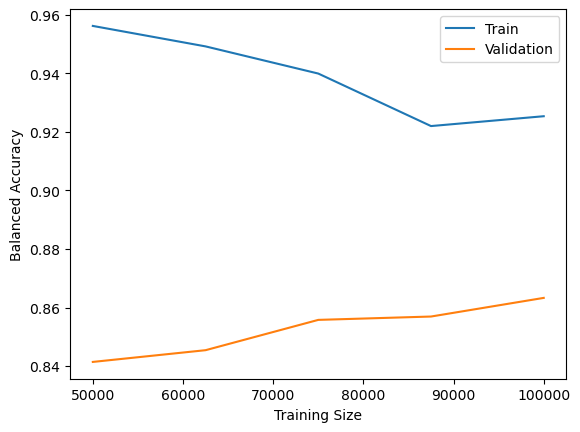

In [34]:
X_sample, y_sample = resample(X, y, n_samples=150_000, stratify=y, random_state=42)

train_sizes, train_scores, test_scores = learning_curve(
    xgb, X_sample, y_sample, cv=3, scoring='balanced_accuracy',
    train_sizes=np.linspace(0.5, 1.0, 5),
    error_score=np.nan,
    n_jobs=-1,   
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label='Train')
plt.plot(train_sizes, test_mean, label='Validation')
plt.xlabel('Training Size')
plt.ylabel('Balanced Accuracy')
plt.legend()
plt.show()

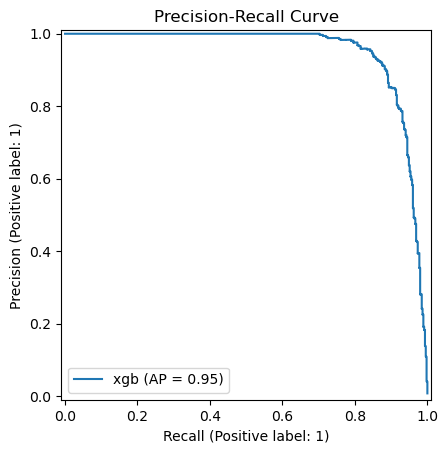

In [57]:
display = PrecisionRecallDisplay.from_estimator(
    random_search.best_estimator_, X_test, y_test, name="xgb"
)
plt.title("Precision-Recall Curve")
plt.show()

In [ ]:
import joblib

# Save the model
joblib.dump(xgb , 'parameters/xgb_fraud_model.pkl')

['parameters/xgb_fraud_model.pkl']